In [1]:
import pandas as pd 
import numpy as np

In [2]:
excel_path = "C:\\Users\\91832\\Desktop\\Pdf_Report\\data\\analytics-data-2026-01-13T13-06-46.xlsx"

xls = pd.ExcelFile(excel_path)

sheet_names = xls.sheet_names
print("Sheet names:", sheet_names)

Sheet names: ['Summary', 'Location Data', 'Application Performance', 'Provider Statistics', 'Technology Statistics', 'Band Analysis', 'PCI Analysis']


In [3]:
for sheet in sheet_names:
    df = xls.parse(sheet, nrows=5)
    print(f"\nSheet: {sheet}")
    print(df.columns.tolist())



Sheet: Summary
['📊 ANALYTICS EXPORT REPORT', 'Unnamed: 1']

Sheet: Location Data
['Sample #', 'Latitude', 'Longitude', 'Operator', 'Provider', 'Technology', 'Band', 'PCI', 'Cell ID', 'RSRP (dBm)', 'RSRQ (dB)', 'SINR (dB)', 'DL Throughput (Mbps)', 'UL Throughput (Mbps)', 'MOS', 'Latency (ms)', 'Jitter (ms)', 'Speed (m/s)', 'Speed (km/h)', 'Timestamp']

Sheet: Application Performance
['Session ID', 'Application', 'Duration (HH:MM:SS)', 'Samples', 'MOS Score', 'Avg RSRP (dBm)', 'Avg RSRQ (dB)', 'Avg SINR (dB)', 'Avg DL (Mbps)', 'Avg UL (Mbps)', 'Avg Latency (ms)', 'Avg Jitter (ms)', 'Avg Packet Loss (%)', 'First Used', 'Last Used']

Sheet: Provider Statistics
['Provider', 'Sample Count', 'Avg RSRP (dBm)', 'Avg RSRQ (dB)', 'Avg SINR (dB)', 'Avg DL (Mbps)', 'Avg UL (Mbps)', 'Avg MOS', 'Avg Latency (ms)']

Sheet: Technology Statistics
['Technology', 'Sample Count', 'Avg RSRP (dBm)', 'Avg SINR (dB)', 'Avg DL (Mbps)', 'Avg UL (Mbps)']

Sheet: Band Analysis
['Band', 'Sample Count', 'Unique PCI

In [4]:
gps_df = xls.parse("Location Data")
print(gps_df.head())

   Sample #   Latitude  Longitude  Operator Provider Technology Band  PCI  \
0         1  28.630554   77.23024       NaN   Airtel         4G  B40  364   
1         2  28.630554   77.23024       NaN   Airtel         4G  B40  364   
2         3  28.630552   77.23024       NaN   Airtel         4G  B40  364   
3         4  28.630554   77.23024       NaN   Airtel         4G  B40  364   
4         5  28.630554   77.23025       NaN   Airtel         4G  B40  364   

   Cell ID  RSRP (dBm)  RSRQ (dB)  SINR (dB)  DL Throughput (Mbps)  \
0   600751       -88.0       -8.0       10.0                   NaN   
1   600751       -88.0       -8.0       10.0                   NaN   
2   600751       -88.0       -8.0       10.0                   NaN   
3   600751       -88.0       -8.0       10.0                   NaN   
4   600751       -88.0       -8.0       10.0                   NaN   

   UL Throughput (Mbps)   MOS  Latency (ms)  Jitter (ms)  Speed (m/s)  \
0                   NaN  4.03         30.52

In [5]:
gps_df[['Latitude', 'Longitude']].isnull().sum()



Latitude     0
Longitude    0
dtype: int64

In [6]:
gps_df = gps_df.dropna(subset=['Latitude', 'Longitude'])

In [7]:
gps_df = gps_df[
    (gps_df['Latitude'].between(-90, 90)) &
    (gps_df['Longitude'].between(-180, 180))
]


In [8]:

center_lat = gps_df['Latitude'].mean()
center_lon = gps_df['Longitude'].mean()     
print(center_lat, center_lon)




28.63103586234141 77.25015066383044


In [9]:
# Downsample GPS points
gps_route = gps_df[['Latitude', 'Longitude']].iloc[::10]  # every 10th point


In [10]:
from shapely.geometry import LineString

line = LineString(zip(gps_route['Latitude'], gps_route['Longitude']))

# tolerance in degrees (~5–10 meters)
simplified_line = line.simplify(tolerance=0.0001, preserve_topology=True)

simplified_coords = [(lat, lon) for lat, lon in simplified_line.coords]
print(f"Simplified from {len(gps_route)} to {len(simplified_coords)} points")

Simplified from 1317 to 434 points


In [11]:
import folium
import os
from shapely.geometry import LineString

os.makedirs("app/maps", exist_ok=True)

# 1. Downsample
gps_route = gps_df[['Latitude', 'Longitude']].iloc[::10]

# 2. Simplify
line = LineString(zip(gps_route['Latitude'], gps_route['Longitude']))
simplified_line = line.simplify(tolerance=0.0001, preserve_topology=True)

route_coords = [(lat, lon) for lat, lon in simplified_line.coords]

# 3. Map
base_map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=14,
    tiles="OpenStreetMap",
    control_scale=True
)

folium.PolyLine(
    locations=route_coords,
    color="blue",
    weight=3,
    opacity=0.9
).add_to(base_map)

base_map.fit_bounds([
    [gps_df['Latitude'].min(), gps_df['Longitude'].min()],
    [gps_df['Latitude'].max(), gps_df['Longitude'].max()]
])

base_map.save("app/maps/base_route_clean.html")


In [66]:
def parse_wkt_polygon(wkt: str):
    """
    Parse a WKT POLYGON string into a list of (lat, lon) tuples.
    """
    wkt = wkt.strip()

    if not wkt.upper().startswith("POLYGON"):
        raise ValueError("Input is not a valid POLYGON WKT")

    # Remove 'POLYGON ((' and '))'
    coord_text = wkt[wkt.find("((") + 2 : wkt.rfind("))")]

    coordinates = []
    for point in coord_text.split(","):
        lat, lon = map(float, point.strip().split())
        coordinates.append((lat, lon))

    return coordinates


In [67]:
wkt = "POLYGON ((28.6961149859279 77.1163067263089,28.6975784027929 77.1166929644071,28.6988159387075 77.1175512712919,28.6988347604335 77.118656341406,28.6962843857118 77.1178409498655,28.6946562542212 77.119385902258,28.6942045138283 77.1185275953733,28.6954185617136 77.1173366945707,28.6948444788096 77.1168217104398,28.6933607055951 77.1172453217463,28.6929277823995 77.1173204235987,28.6930501304406 77.1163226418452,28.6958640959192 77.1156896405176,28.6961149859279 77.1163067263089))"

coords =  parse_wkt_polygon(wkt)
print(coords)   

[(28.6961149859279, 77.1163067263089), (28.6975784027929, 77.1166929644071), (28.6988159387075, 77.1175512712919), (28.6988347604335, 77.118656341406), (28.6962843857118, 77.1178409498655), (28.6946562542212, 77.119385902258), (28.6942045138283, 77.1185275953733), (28.6954185617136, 77.1173366945707), (28.6948444788096, 77.1168217104398), (28.6933607055951, 77.1172453217463), (28.6929277823995, 77.1173204235987), (28.6930501304406, 77.1163226418452), (28.6958640959192, 77.1156896405176), (28.6961149859279, 77.1163067263089)]


In [12]:
import asyncio
from playwright.async_api import async_playwright
import os

async def export_map_png():
    html_path = os.path.abspath("app/maps/base_route_clean.html")
    png_path = "app/maps/base_route_clean.png"

    async with async_playwright() as p:
        browser = await p.chromium.launch()
        page = await browser.new_page(
            viewport={"width": 1600, "height": 1000},
            device_scale_factor=2  # high DPI
        )
        await page.goto(f"file:///{html_path}")
        await page.wait_for_timeout(4000)  # wait for tiles
        await page.screenshot(path=png_path)
        await browser.close()

    return png_path



In [13]:
rsrq_df = gps_df[gps_df['RSRQ (dB)'].notnull()].copy()
print(rsrq_df[['RSRQ (dB)']].describe())

          RSRQ (dB)
count  13163.000000
mean     -11.720884
std        2.969768
min      -29.000000
25%      -14.000000
50%      -12.000000
75%       -9.000000
max       -6.000000


In [14]:
def rsrq_color_manual(rsrq):
    if -20 <= rsrq <= -18:
        return "#1f77b4"  # Blue
    elif -17 <= rsrq <= -16:
        return "#ff7f0e"  # yellow
    elif -15 <= rsrq <= -14:
        return "#2ca02c"  # Green
    elif -14 <= rsrq <= 0:
        return "#d62728"  # Red
    else:
        return "#d3d3d3"  # Light Grey for out of range

In [15]:
bins = {
    "blue (-20 to -18)": rsrq_df[(rsrq_df['RSRQ (dB)'] >= -20) & (rsrq_df['RSRQ (dB)'] <= -18)].shape[0],
    "yellow (-17 to -16)": rsrq_df[(rsrq_df['RSRQ (dB)'] >= -17) & (rsrq_df['RSRQ (dB)'] <= -16)].shape[0],
    "green (-15 to -14)": rsrq_df[(rsrq_df['RSRQ (dB)'] >= -15) & (rsrq_df['RSRQ (dB)'] <= -14)].shape[0],
    "Red (-14 to 0)": rsrq_df[(rsrq_df['RSRQ (dB)'] > -14) & (rsrq_df['RSRQ (dB)'] <= 0)].shape[0],
}

for k, v in bins.items():
    print(f"{k}: {v}")


blue (-20 to -18): 433
yellow (-17 to -16): 785
green (-15 to -14): 2281
Red (-14 to 0): 9628


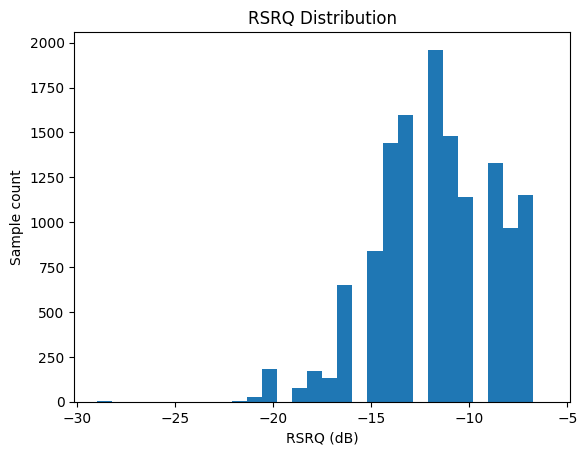

In [16]:
import matplotlib.pyplot as plt

plt.hist(rsrq_df['RSRQ (dB)'], bins=30)
plt.xlabel("RSRQ (dB)")
plt.ylabel("Sample count")
plt.title("RSRQ Distribution")
plt.show()


In [17]:


rsrq_map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=14,
    tiles="OpenStreetMap",
    control_scale=True
)

for _, row in rsrq_df.iterrows():
    colour = rsrq_color_manual(row['RSRQ (dB)'])   
    folium.CircleMarker(
        location=[row['Latitude'],row["Longitude"]],
        radius=1.5,
        fill_color=colour,
        fill=True,
        fill_opacity=0.7,
        weight=0
    ).add_to(rsrq_map)

rsrq_map.fit_bounds([
    [gps_df['Latitude'].min(), gps_df['Longitude'].min()],
    [gps_df['Latitude'].max(), gps_df['Longitude'].max()]
])

rsrq_map.save("maps/rsrq_map.html")
print("RSRQ map saved to maps/rsrq_map.html")

RSRQ map saved to maps/rsrq_map.html


In [18]:
rsrp_df = gps_df[gps_df['RSRP (dBm)'].notnull()].copy()
print(rsrp_df[['RSRP (dBm)']].describe())

         RSRP (dBm)
count  13163.000000
mean     -80.702727
std       11.375135
min     -117.000000
25%      -88.000000
50%      -81.000000
75%      -72.000000
max      -58.000000


In [19]:
def rsrp_colour_manual(rsrq):
    if -124 <= rsrq <= -105:
        return "#1f77b4"  # Blue
    elif -105 <= rsrq <= -95:
        return "#ff7f0e"  # yellow
    elif -95 <= rsrq <= -75:
        return "#2ca02c"  # Green
    elif -75 <= rsrq <= -60:
        return "#d62728"  # Red
    elif -60 < rsrq <= 50:
        return "#9467bd"  # Purple
    else:
        return "#d3d3d3"  # Light Grey for out of range

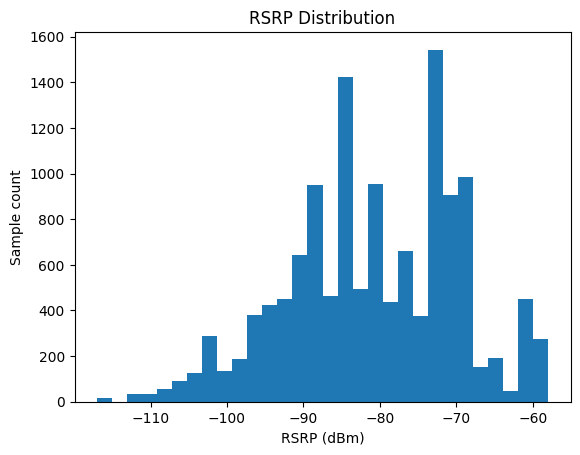

In [20]:
plt.hist(rsrp_df['RSRP (dBm)'], bins=30)
plt.xlabel("RSRP (dBm)")    
plt.ylabel("Sample count")
plt.title("RSRP Distribution")
plt.show()

In [21]:
rsrp_map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=14,
    tiles="OpenStreetMap",
    control_scale=True
)

for _, row in rsrp_df.iterrows():
    colour = rsrp_colour_manual(row['RSRP (dBm)'])   
    folium.CircleMarker(
        location=[row['Latitude'],row["Longitude"]],
        radius=1.5,
        fill_color=colour,
        fill=True,
        fill_opacity=0.7,
        weight=0
    ).add_to(rsrp_map)

rsrp_map.fit_bounds([
    [gps_df['Latitude'].min(), gps_df['Longitude'].min()],
    [gps_df['Latitude'].max(), gps_df['Longitude'].max()]
])

rsrp_map.save("maps/rsrp_map.html")
print("RSRP map saved to maps/rsrp_map.html")

RSRP map saved to maps/rsrp_map.html


In [22]:
def sinr_color_manual(sinr):
    if -20 <= sinr <= 1:
        return "#1f77b4"  # Blue
    elif 1 <= sinr <= 5:
        return "#ff7f0e"  # yellow
    elif 5 <= sinr <= 10:
        return "#2ca02c"  # Green
    elif 10 <= sinr <= 15:
        return "#d62728"  # Red
    elif 15 < sinr <= 30:
        return "#9467bd"  # Purple
    else:
        return "#d3d3d3"  

In [23]:
def dl_colour_manual(dl):
    if 0 <=dl <= 5:
        return "#d73027"   # red
    elif 5 < dl <= 20:
        return "#fdae61"   # orange
    elif 20 < dl <= 30:
        return "#006400"   #  green
    else:
        return "#808080"   # gray


In [24]:
def ul_colour_manual(ul):
    if 2 <=ul <= 5:
        return "#d73027"   # red
    elif 5 < ul <= 10:
        return "#fdae61"   # orange
    elif 10 < ul <= 15:
        return "#ffff00"   # yellow
    elif 15 < ul <= 30:
        return "#006400"   # green
    else:
        return "#808080"   # gray


In [25]:
def mos_colour_manual(mos):
    if 0 <= mos < 1:
        return "#d73027"   # red
    elif 1 <= mos < 3:
        return "#fdae61"   # orange
    elif 3 <= mos < 5:
        return "#ffff00"   # yellow
    else:
        return "#808080"   # gray


In [26]:
KPI_CONFIG = {
    "RSRP": {
        "column": "RSRP (dBm)",
        "map_name": "rsrp_map",
        "color_func": rsrp_colour_manual
    },
    "RSRQ": {
        "column": "RSRQ (dB)",
        "map_name": "rsrq_map",
        "color_func": rsrq_color_manual
    },
    "SINR": {
        "column": "SINR (dB)",
        "map_name": "sinr_map",
        "color_func": sinr_color_manual
    },
    "DL": {
        "column": "DL Throughput (Mbps)",
        "map_name": "dl_map",
        "color_func": dl_colour_manual
    },
    "UL": {
        "column": "UL Throughput (Mbps)",
        "map_name": "ul_map",
        "color_func": ul_colour_manual
    },
    "MOS": {
        "column": "MOS",
        "map_name": "mos_map",
        "color_func": mos_colour_manual
    }
}


In [27]:
def generate_kpi_map(df, kpi_column, color_func, output_name):
    kpi_map = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=14,
        tiles="OpenStreetMap",
        control_scale=True
    )

    for _, row in df.iterrows():
        color = color_func(row[kpi_column])

        folium.CircleMarker(
            location=[row['Latitude'], row['Longitude']],
            radius=1.5,
            fill=True,
            fill_color=color,
            fill_opacity=0.7,
            weight=0
        ).add_to(kpi_map)

    kpi_map.fit_bounds([
        [df['Latitude'].min(), df['Longitude'].min()],
        [df['Latitude'].max(), df['Longitude'].max()]
    ])

    kpi_map.save(f"maps/{output_name}.html")
    print(f"{output_name} saved")


In [28]:
for kpi, cfg in KPI_CONFIG.items():
    df_kpi = gps_df[gps_df[cfg["column"]].notna()].copy()

    generate_kpi_map(
        df=df_kpi,
        kpi_column=cfg["column"],
        color_func=cfg["color_func"],
        output_name=cfg["map_name"]
    )


rsrp_map saved
rsrq_map saved
sinr_map saved
dl_map saved
ul_map saved
mos_map saved


In [29]:
HIST_CONFIG = [
    {"key": "RSRP", "column": "RSRP (dBm)", "title": "RSRP Distribution"},
    {"key": "RSRQ", "column": "RSRQ (dB)", "title": "RSRQ Distribution"},
    {"key": "SINR", "column": "SINR (dB)", "title": "SINR Distribution"},
    {"key": "DL", "column": "DL Throughput (Mbps)", "title": "DL Throughput Distribution"},
    {"key": "UL", "column": "UL Throughput (Mbps)", "title": "UL Throughput Distribution"},
    {"key": "MOS", "column": "MOS", "title": "MOS Distribution"},
]


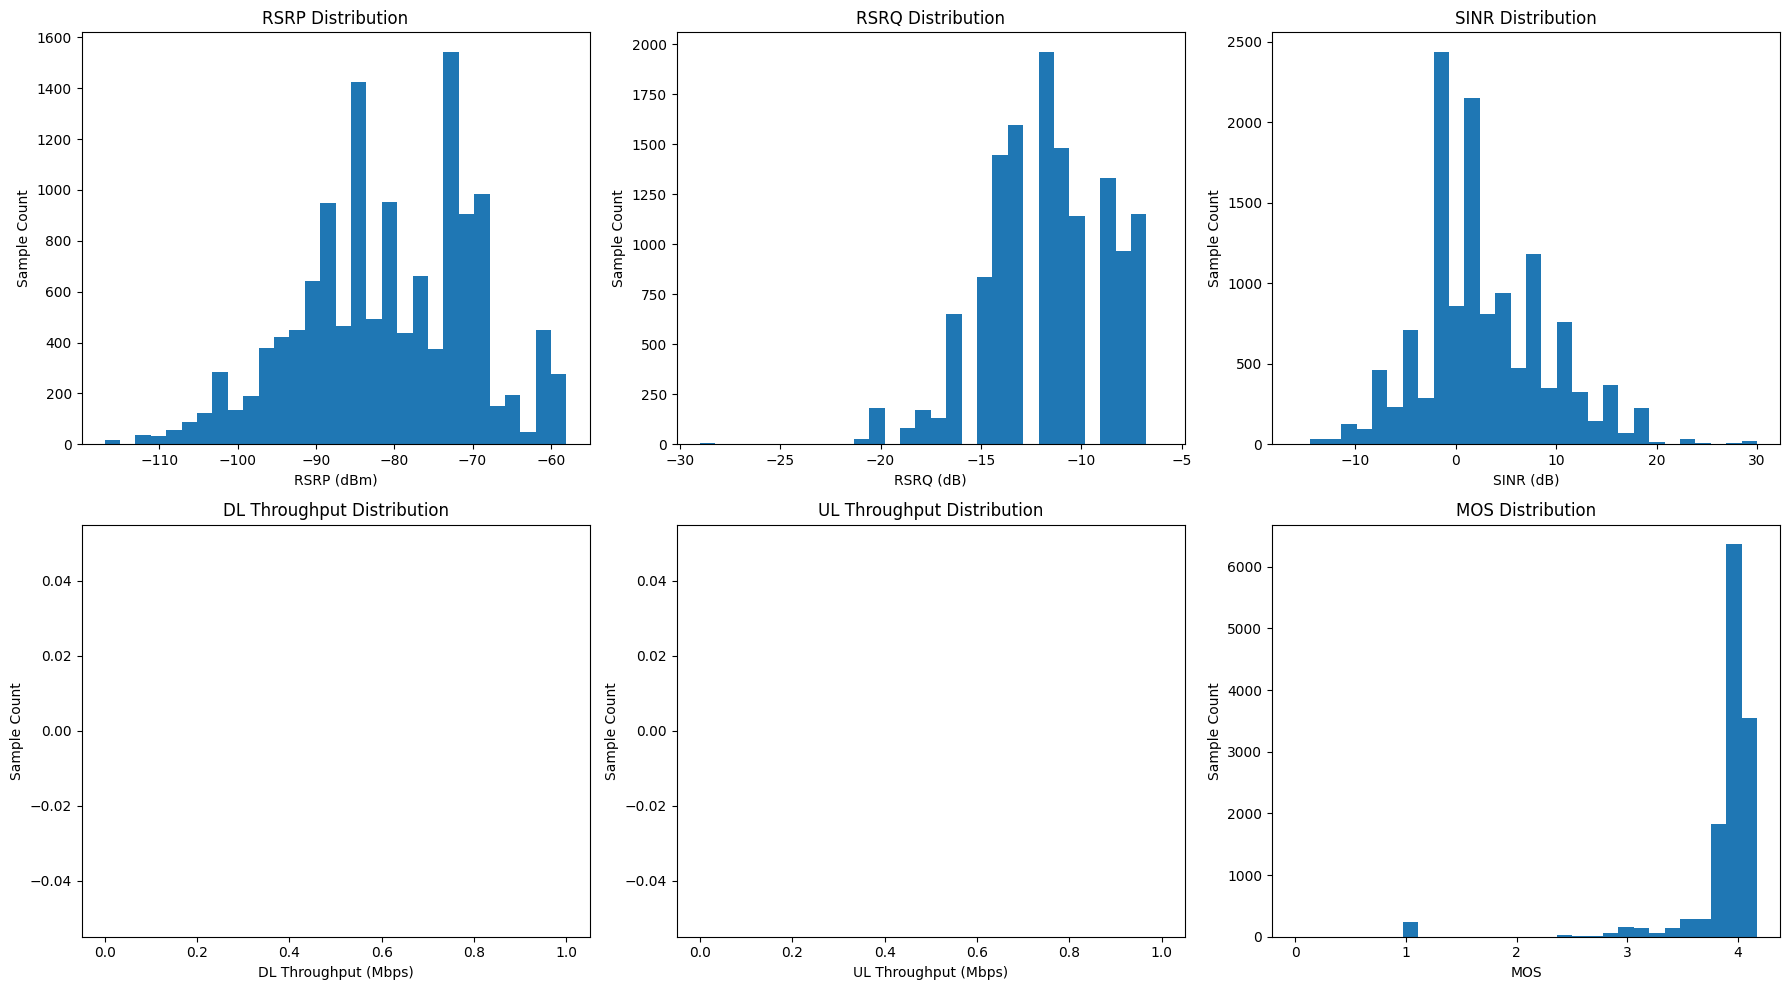

In [30]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, cfg in enumerate(HIST_CONFIG):
    col = cfg["column"]
    ax = axes[idx]

    df_kpi = gps_df[gps_df[col].notna()]

    ax.hist(df_kpi[col], bins=30)
    ax.set_title(cfg["title"])
    ax.set_xlabel(col)
    ax.set_ylabel("Sample Count")

# Remove empty subplots if any
for j in range(len(HIST_CONFIG), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [31]:
pci_counts = gps_df['PCI'].value_counts()
print(pci_counts)

PCI
172    837
205    743
502    616
436    474
417    387
      ... 
257      2
236      2
241      1
234      1
345      1
Name: count, Length: 163, dtype: int64


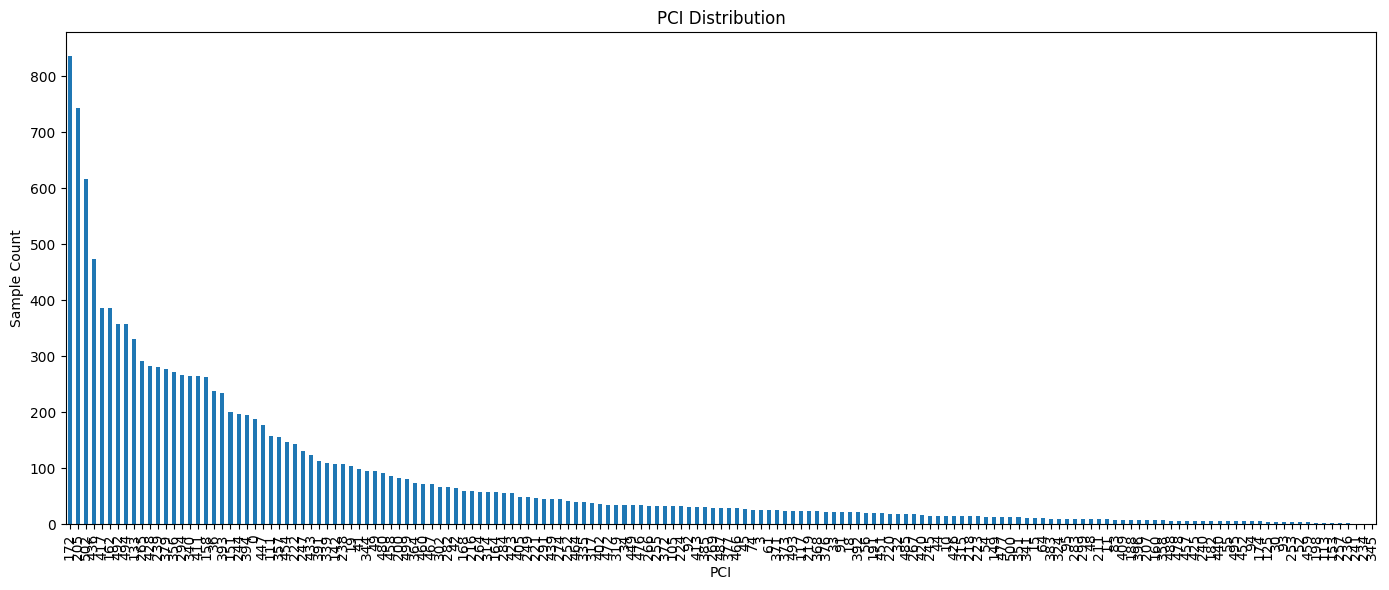

In [32]:
plt.figure(figsize=(14,6))
pci_counts.plot(kind='bar')
plt.title("PCI Distribution")   
plt.xlabel("PCI")
plt.ylabel("Sample Count")
plt.tight_layout()
plt.show()

In [33]:
TOP_PCI = 25

pci_counts = gps_df['PCI'].value_counts()
top_pcis = pci_counts.head(TOP_PCI).index.tolist()

print("Top 25 PCI:")
print(pci_counts.head(TOP_PCI))


Top 25 PCI:
PCI
172    837
205    743
502    616
436    474
417    387
162    387
492    358
494    358
133    330
265    292
428    282
239    280
379    278
356    272
294    266
340    265
411    265
158    263
36     237
393    234
151    200
244    197
394    195
0      188
447    177
Name: count, dtype: int64


In [34]:
DEFAULT_PCI_COLOR = "#"  # black for non-top PCI

import random
import folium
import os

def random_color():
    return "#{:06x}".format(random.randint(0, 0xFFFFFF))



# Assign random colors ONLY to top PCI
pci_color_map = {
    pci: random_color()
    for pci in top_pcis
}

os.makedirs("maps", exist_ok=True)

pci_map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=14,
    tiles="OpenStreetMap",
    control_scale=True
)

# LOOP OVER FULL DATASET
for _, row in gps_df[gps_df['PCI'].notna()].iterrows():

    color = pci_color_map.get(row['PCI'], DEFAULT_PCI_COLOR)

    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=1.4 if row['PCI'] in pci_color_map else 1.0,
        fill=True,
        fill_color=color,
        fill_opacity=0.75 if row['PCI'] in pci_color_map else 0.35,
        weight=0
    ).add_to(pci_map)

pci_map.fit_bounds([
    [gps_df['Latitude'].min(), gps_df['Longitude'].min()],
    [gps_df['Latitude'].max(), gps_df['Longitude'].max()]
])

pci_map.save("maps/pci_map_top25_with_others.html")
print("PCI map saved: Top 25 colored, others gray")


PCI map saved: Top 25 colored, others gray


In [35]:
gps_df["Band"].value_counts()

Band
B8     5623
B40    4014
B1     2451
B3     1075
Name: count, dtype: int64

In [36]:
import random

def random_color():
    return "#{:06x}".format(random.randint(0, 0xFFFFFF))

# Get all unique Band values
unique_bands = gps_df['Band'].dropna().unique()

# Assign random color per Band
band_color_map = {
    band: random_color()
    for band in unique_bands
}

print("Total bands:", len(band_color_map))
print("Bands:", band_color_map.keys())


Total bands: 4
Bands: dict_keys(['B40', 'B3', 'B1', 'B8'])


In [37]:
import folium
import os

os.makedirs("maps", exist_ok=True)

band_map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=14,
    tiles="OpenStreetMap",
    control_scale=True
)

for _, row in gps_df[gps_df['Band'].notna()].iterrows():
    color = band_color_map[row['Band']]

    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=1.4,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        weight=0
    ).add_to(band_map)

band_map.fit_bounds([
    [gps_df['Latitude'].min(), gps_df['Longitude'].min()],
    [gps_df['Latitude'].max(), gps_df['Longitude'].max()]
])

band_map.save("maps/band_map_all.html")
print("Band map saved (all bands, random colors)")


Band map saved (all bands, random colors)


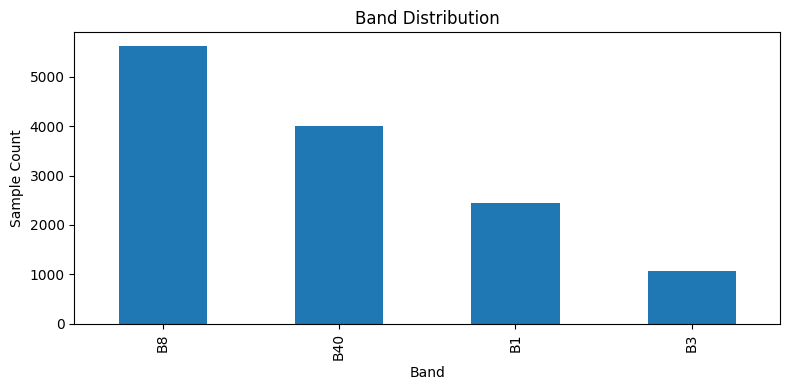

In [38]:
band_counts = gps_df['Band'].value_counts()

plt.figure(figsize=(8, 4))
band_counts.plot(kind='bar')
plt.title("Band Distribution")
plt.xlabel("Band")
plt.ylabel("Sample Count")
plt.tight_layout()
plt.show()


In [39]:
import pandas as pd

# KPI configuration: display name -> column name
KPI_COLUMNS = {
    "RSRP": "RSRP (dBm)",
    "RSRQ": "RSRQ (dB)",
    "SINR": "SINR (dB)",
    "DL Throughput": "DL Throughput (Mbps)",
    "UL Throughput": "UL Throughput (Mbps)",
    "MOS": "MOS"
}

summary_rows = []

for kpi_name, col in KPI_COLUMNS.items():

    # Skip if column does not exist
    if col not in gps_df.columns:
        continue

    # Drop NaN values
    values = gps_df[col].dropna()

    # Skip KPI if no valid values
    if values.empty:
        continue

    summary_rows.append({
        "KPI": kpi_name,
        "Average": round(values.mean(), 2),
        "Min": round(values.min(), 2),
        "Max": round(values.max(), 2),
        "Median": round(values.median(), 2)
    })

# Create summary DataFrame
kpi_summary_df = pd.DataFrame(summary_rows)

kpi_summary_df


,KPI,Average,Min,Max,Median
0,RSRP,-80.70,-117.0,-58.00,-81.00
1,RSRQ,-11.72,-29.0,-6.00,-12.00
2,SINR,2.77,-16.0,30.00,2.00
3,MOS,3.87,0.0,4.17,3.98


In [40]:
import matplotlib.pyplot as plt

# Create figure
fig, ax = plt.subplots(figsize=(10, 0.6 * len(kpi_summary_df) + 1))
ax.axis('off')

# Prepare table data
table_data = [kpi_summary_df.columns.tolist()] + kpi_summary_df.values.tolist()

# Create table
table = ax.table(
    cellText=table_data,
    loc='center',
    cellLoc='center'
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)

# Header styling
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#e6e6e6')
    else:
        cell.set_facecolor('white')

# Save image
plt.savefig("maps/kpi_summary.png", dpi=300, bbox_inches='tight')
plt.close()

print("KPI summary image saved as maps/kpi_summary.png")


KPI summary image saved as maps/kpi_summary.png


In [41]:
import pandas as pd

# Drop NaN bands
band_df = gps_df[gps_df['Band'].notna()].copy()

# Count samples per band
band_counts = band_df['Band'].value_counts().reset_index()
band_counts.columns = ['Band', 'Sample Count']

# Percentage calculation
total_samples = band_counts['Sample Count'].sum()
band_counts['Sample Percentage (%)'] = (
    band_counts['Sample Count'] / total_samples * 100
).round(2)

band_counts


,Band,Sample Count,Sample Percentage (%)
0,B8,5623,42.72
1,B40,4014,30.49
2,B1,2451,18.62
3,B3,1075,8.17


In [42]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 0.6 * len(band_counts) + 1))
ax.axis('off')

table_data = [band_counts.columns.tolist()] + band_counts.values.tolist()

table = ax.table(
    cellText=table_data,
    loc='center',
    cellLoc='center'
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#e6e6e6')
    else:
        cell.set_facecolor('white')

plt.savefig("maps/band_summary.png", dpi=300, bbox_inches='tight')
plt.close()

print("Band summary table saved as maps/band_summary.png")


Band summary table saved as maps/band_summary.png


In [43]:
plt.figure(figsize=(6, 6))

plt.pie(
    band_counts['Sample Percentage (%)'],
    labels=band_counts['Band'],
    autopct='%1.1f%%',
    startangle=90
)

plt.axis('equal')  # circle
plt.tight_layout()

plt.savefig("maps/band_pie.png", dpi=300, bbox_inches='tight')
plt.close()

print("Band pie chart saved as maps/band_pie.png")


Band pie chart saved as maps/band_pie.png


In [45]:
import pyodbc
print(pyodbc.drivers())


['SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)', 'ODBC Driver 17 for SQL Server', 'ODBC Driver 18 for SQL Server']


In [47]:
lat_center = gps_df['Latitude'].mean()
lon_center = gps_df['Longitude'].mean()

In [48]:
from geopy.geocoders import Nominatim

geolocator = Nominatim(user_agent="demo-report")

location = geolocator.reverse((lat_center, lon_center))
address = location.raw["address"]

city = (
    address.get("city")
    or address.get("town")
    or address.get("village")
    or "Unknown"
)

country = address.get("country", "Unknown")
print(f"Center Location: {city}, {country}")




Center Location: Delhi, India


In [49]:
sample_df = gps_df.sample(n=60, random_state=42)
print(sample_df.head())

      Sample #   Latitude  Longitude  Operator  Provider Technology Band  PCI  \
8278      8279  28.634851  77.216300       NaN    Airtel         4G  B40   41   
5118      5119  28.630700  77.216225       NaN  VI India         4G   B3  151   
8351      8352  28.634686  77.216700       NaN  VI India         4G   B8   19   
5786      5787  28.629644  77.214584       NaN  VI India         4G   B8  111   
3477      3478  28.634320  77.217200       NaN  VI India         4G   B8  244   

      Cell ID  RSRP (dBm)  RSRQ (dB)  SINR (dB)  DL Throughput (Mbps)  \
8278   925792       -97.0      -13.0        4.0                   NaN   
5118   882775       -72.0       -7.0        7.0                   NaN   
8351   433893      -102.0      -20.0        4.0                   NaN   
5786   422155       -76.0       -7.0        3.0                   NaN   
3477   432034       -90.0      -14.0       -2.0                   NaN   

      UL Throughput (Mbps)   MOS  Latency (ms)  Jitter (ms)  Speed (m/s)  

In [50]:

print(sample_df.dtypes)


Sample #                  int64
Latitude                float64
Longitude               float64
Operator                float64
Provider                 object
Technology               object
Band                     object
PCI                       int64
Cell ID                   int64
RSRP (dBm)              float64
RSRQ (dB)               float64
SINR (dB)               float64
DL Throughput (Mbps)    float64
UL Throughput (Mbps)    float64
MOS                     float64
Latency (ms)            float64
Jitter (ms)             float64
Speed (m/s)             float64
Speed (km/h)            float64
Timestamp                object
dtype: object


In [51]:
loc = geolocator.reverse(
    (sample_df.iloc[0].Latitude, sample_df.iloc[0].Longitude),
    zoom=16,
    language="en"
)

print(loc.raw["address"])


{'road': 'Panchkuian Road', 'neighbourhood': 'Palika Niketan', 'suburb': 'Connaught Place', 'city': 'New Delhi', 'ISO3166-2-lvl4': 'IN-DL', 'postcode': '110055', 'country': 'India', 'country_code': 'in'}


In [52]:
from collections import Counter
import time

areas = []

for _, row in sample_df.iterrows():
    try:
        loc = geolocator.reverse(
            (row.Latitude, row.Longitude),
            zoom=16,
            language="en"
        )
        addr = loc.raw.get("address", {})

        area = (
            addr.get("suburb")          # Connaught Place
            or addr.get("city_district")
            or addr.get("neighbourhood")
            or addr.get("locality")
        )

        if area:
            areas.append(area)

        time.sleep(1)

    except Exception as e:
        print("ERROR:", e)


In [53]:
covered_areas = [
    area for area, _ in Counter(areas).most_common(6)
]

print("Covered Areas:", covered_areas)


Covered Areas: ['Connaught Place', 'Mayur Vihar Tehsil', 'Kotwali Tehsil', 'Shakarpur', 'Chanakya Puri Tehsil', 'Indirapuram']


In [54]:
band_json = []

for _, row in band_counts.iterrows():
    band_json.append({
        "band": row["Band"],
        "sample_count": int(row["Sample Count"]),
        "sample_percentage": float(row["Sample Percentage (%)"])
    })
print(band_json)

[{'band': 'B8', 'sample_count': 5623, 'sample_percentage': 42.72}, {'band': 'B40', 'sample_count': 4014, 'sample_percentage': 30.49}, {'band': 'B1', 'sample_count': 2451, 'sample_percentage': 18.62}, {'band': 'B3', 'sample_count': 1075, 'sample_percentage': 8.17}]


In [55]:
rsrp_json = {
    "average": round(gps_df["RSRP (dBm)"].mean(), 2),
    "median": round(gps_df["RSRP (dBm)"].median(), 2),
    "min": round(gps_df["RSRP (dBm)"].min(), 2),
    "max": round(gps_df["RSRP (dBm)"].max(), 2)
}
print(rsrp_json)

{'average': np.float64(-80.7), 'median': np.float64(-81.0), 'min': np.float64(-117.0), 'max': np.float64(-58.0)}


In [56]:
pci_json = {
    "total_unique_pci": int(gps_df["PCI"].nunique()),
    "top_30_pci_percentage": round(
        gps_df["PCI"].value_counts(normalize=True).head(30).sum() * 100, 2
    )
}
print(pci_json)

{'total_unique_pci': 163, 'top_30_pci_percentage': np.float64(69.24)}


In [57]:
rsrq_json = {
    "average": round(gps_df["RSRQ (dB)"].mean(), 2),
    "median": round(gps_df["RSRQ (dB)"].median(), 2),
    "min": round(gps_df["RSRQ (dB)"].min(), 2),
    "max": round(gps_df["RSRQ (dB)"].max(), 2)  
}
print(rsrq_json)

{'average': np.float64(-11.72), 'median': np.float64(-12.0), 'min': np.float64(-29.0), 'max': np.float64(-6.0)}


In [58]:
mos_json = {
    "average": round(gps_df["MOS"].mean(), 2),  
    "median": round(gps_df["MOS"].median(), 2),
    "min": round(gps_df["MOS"].min(), 2),
    "max": round(gps_df["MOS"].max(), 2)        

}
print(mos_json)

{'average': np.float64(3.87), 'median': np.float64(3.98), 'min': np.float64(0.0), 'max': np.float64(4.17)}


In [59]:
import math
import pandas as pd

def safe_kpi_block(df, col):
    series = df[col].dropna()

    if series.empty:
        return None  

    return {
        "average": round(series.mean(), 2),
        "median": round(series.median(), 2),
        "min": round(series.min(), 2),
        "max": round(series.max(), 2)
    }


In [ ]:
import json

# -----------------------------
# 1. KPI SUMMARY
# -----------------------------

def  kpi_block(df, col):
    return {
        "average": round(df[col].mean(), 2),
        "median": round(df[col].median(), 2),
        "min": round(df[col].min(), 2),
        "max": round(df[col].max(), 2)
    }

kpi_summary = {}

rsrp = safe_kpi_block(gps_df, "RSRP (dBm)")
if rsrp:
    kpi_summary["RSRP"] = { "unit": "dBm", **rsrp }

rsrq = safe_kpi_block(gps_df, "RSRQ (dB)")
if rsrq:
    kpi_summary["RSRQ"] = { "unit": "dB", **rsrq }

sinr = safe_kpi_block(gps_df, "SINR (dB)")
if sinr:
    kpi_summary["SINR"] = { "unit": "dB", **sinr }

dl = safe_kpi_block(gps_df, "DL Throughput (Mbps)")
if dl:
    kpi_summary["DL_Throughput"] = { "unit": "Mbps", **dl }

ul = safe_kpi_block(gps_df, "UL Throughput (Mbps)")
if ul:
    kpi_summary["UL_Throughput"] = { "unit": "Mbps", **ul }

mos = safe_kpi_block(gps_df, "MOS")
if mos:
    kpi_summary["MOS"] = mos
# -----------------------------
# 2. BAND SUMMARY
# -----------------------------

band_df = gps_df[gps_df["Band"].notna()].copy()
band_counts = band_df["Band"].value_counts().reset_index()
band_counts.columns = ["band", "sample_count"]

total_band_samples = band_counts["sample_count"].sum()
band_counts["sample_percentage"] = (
    band_counts["sample_count"] / total_band_samples * 100
).round(2)

band_summary = band_counts.to_dict(orient="records")

# -----------------------------
# 3. PCI SUMMARY
# -----------------------------

pci_summary = {
    "total_unique_pci": int(gps_df["PCI"].nunique()),
    "top_30_pci_percentage": round(
        gps_df["PCI"]
        .value_counts(normalize=True)
        .head(30)
        .sum() * 100,
        2
    )
}

# -----------------------------
# 4. AREA SUMMARY
# -----------------------------

area_summary = {
    "covered_areas": covered_areas
}

# -----------------------------
# 5. LOCATION
# -----------------------------

location = {
    "city": city,
    "country": country
}

# -----------------------------
# 6. FINAL METADATA JSON
# -----------------------------

metadata = {
    "location": location,
    "area_summary": area_summary,
    "kpi_summary": kpi_summary,
    "band_summary": band_summary,
    "pci_summary": pci_summary
}

# -----------------------------
# 7. WRITE TO FILE
# -----------------------------

with open("metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print(" metadata.json created successfully")


 metadata.json created successfully


In [61]:
LLM_SYSTEM_PROMPT = """
You are a telecom RF reporting engine that writes formal drive-test reports.

CRITICAL: Every section value MUST be a single plain text paragraph.
CRITICAL: NEVER return objects, arrays, or key-value structures as section values.

GENERAL RULES (MANDATORY):
- Output MUST be valid JSON only
- Section values MUST be plain text strings
- Write in neutral, professional telecom report language
- DO NOT evaluate performance (no good/poor/fair/satisfactory)
- DO NOT make recommendations
- DO NOT invent data or fields
- DO NOT mention charts, tables, or images
- Use ONLY the provided metadata
- Each section must be 3–5 complete sentences unless specified otherwise

SECTION-SPECIFIC INSTRUCTIONS:

Introduction:
- Mention the city and country
- State the purpose of the drive test
- Mention that real-world mobility data was analyzed
- Mention that the report focuses on coverage, quality, and performance metrics

Area Summary:
- Describe the geographical spread of the route
- Mention key areas covered (do not list all blindly; summarize)

Drive Summary:
- If no drive details are provided, return an empty string

KPI Summary:
- Describe overall trends using averages and ranges
- Mention RSRP, RSRQ, SINR, and MOS in narrative form
- Do not judge performance
-If no drive details are provided, return an empty string


Map View - Band:
- Describe band distribution and dominance

Map View - RSRP / RSRQ / SINR / DL Throughput / UL Throughput:
- Describe variation and range across the route
- Mention any notable extremes or averages if present 
-if no  data is provided for a KPI, return an empty string 



PCI Summary:
- Describe PCI diversity and dominance using provided counts

OUTPUT FORMAT:
Return ONLY a JSON object with EXACT keys:
Introduction
Area Summary
Drive Summary
KPI Summary
Map View - Band
Map View - RSRP
Map View - RSRQ
Map View - SINR
Map View - DL Throughput
Map View - UL Throughput
PCI Summary
"""


In [62]:
import os
import json
from groq import Groq
from dotenv import load_dotenv
import re

# Load .env
load_dotenv()

# Initialize Groq client
client = Groq(api_key=os.getenv("GROQ_API_KEY"))

# Load metadata.json
with open("metadata.json", "r", encoding="utf-8") as f:
    metadata = json.load(f)

# Build prompt
prompt = f"""
Generate a structured telecom drive-test report using the metadata below.

METADATA:
{json.dumps(metadata, indent=2)}
"""

# Call Groq LLM
response = client.chat.completions.create(
    model="llama-3.1-8b-instant",
    messages=[
        {"role": "system", "content": LLM_SYSTEM_PROMPT},
        {"role": "user", "content": prompt}
    ],
    temperature=0.,   # LOW randomness (important)
    max_tokens=1200
)




# Parse LLM output
llm_output = response.choices[0].message.content.strip()
print("LLM RAW OUTPUT:\n", llm_output)

# Convert string → JSON
def extract_json(text):
    match = re.search(r'\{[\s\S]*\}', text)
    if not match:
        raise ValueError("No JSON object found in LLM output")
    return json.loads(match.group())

report_text = extract_json(llm_output)

def validate_report_text(report_text):
    for key, value in report_text.items():
        if not isinstance(value, str):
            return False, key
    return True, None


is_valid, bad_key = validate_report_text(report_text)

if not is_valid:
    raise ValueError(
        f"LLM returned non-text content for section '{bad_key}'"
    )



# Save output
with open("report_text.json", "w", encoding="utf-8") as f:
    json.dump(report_text, f, indent=2)

print(" report_text.json generated successfully")


LLM RAW OUTPUT:
 ```json
{
  "Introduction": "This report summarizes the results of a drive test conducted in Delhi, India. The purpose of the drive test was to analyze real-world mobility data and assess the network's performance in terms of coverage, quality, and performance metrics. The report focuses on the analysis of various key performance indicators (KPIs) such as RSRP, RSRQ, SINR, and MOS. The drive test route covered various areas in Delhi, including Connaught Place, Mayur Vihar Tehsil, Kotwali Tehsil, Shakarpur, Chanakya Puri Tehsil, and Indirapuram.",
  "Area Summary": "The drive test route covered a significant geographical spread in Delhi, including various commercial and residential areas. Key areas covered include Connaught Place, a major commercial hub, and Mayur Vihar Tehsil, a densely populated residential area. The route also passed through Kotwali Tehsil, a historic area with significant cultural importance.",
  "Drive Summary": "",
  "KPI Summary": "The overall tr

In [65]:
import os
import json
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Image
)
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.pagesizes import A4


# -----------------------------
# Base paths (notebook + script safe)
# -----------------------------
if "__file__" in globals():
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
else:
    BASE_DIR = os.getcwd()

MAPS_DIR = os.path.join(BASE_DIR, "maps")


# -----------------------------
# Load report text
# -----------------------------
with open(os.path.join(BASE_DIR, "report_text.json"), encoding="utf-8") as f:
    report_text = json.load(f)


# -----------------------------
# PDF setup
# -----------------------------
doc = SimpleDocTemplate(
    "final_report.pdf",
    pagesize=A4,
    rightMargin=40,
    leftMargin=40,
    topMargin=40,
    bottomMargin=40
)

styles = getSampleStyleSheet()
story = []


# -----------------------------
# Helpers
# -----------------------------
def add_section(title, text):
    story.append(Paragraph(f"<b>{title}</b>", styles["Heading2"]))
    story.append(Spacer(1, 12))
    if text:
        story.append(Paragraph(text, styles["BodyText"]))
        story.append(Spacer(1, 18))

def add_image(filename, width, height):
    path = os.path.join(MAPS_DIR, filename)
    print("Trying image:", path)
    if os.path.exists(path):
        story.append(Image(path, width=width, height=height))
        story.append(Spacer(1, 15))
    else:
        raise FileNotFoundError(f"Image not found: {path}")


# -----------------------------
# Build report
# -----------------------------

# 1. Introduction
add_section("1. Introduction", report_text["Introduction"])

# 2. Area Summary
add_section("2. Area Summary", report_text["Area Summary"])
add_image("base_route_clean.png", 450, 280)

# 3. Drive Summary
add_section("3. Drive Summary", report_text["Drive Summary"])

# 4. KPI Summary
add_section("4. KPI Summary", report_text["KPI Summary"])
add_image("kpi_summary.png", 450, 250)

# 5. Band Distribution
add_section("5. Band Distribution", report_text["Map View - Band"])
add_image("band_summary.png", 450, 300)
add_image("band_pie.png", 420, 300)

# 6. PCI Summary
add_section("6. PCI Summary", report_text["PCI Summary"])


# -----------------------------
# Build PDF
# -----------------------------
doc.build(story)

print(" final_report.pdf generated successfully")


Trying image: c:\Users\91832\Desktop\Pdf_Report\app\maps\base_route_clean.png
Trying image: c:\Users\91832\Desktop\Pdf_Report\app\maps\kpi_summary.png
Trying image: c:\Users\91832\Desktop\Pdf_Report\app\maps\band_summary.png
Trying image: c:\Users\91832\Desktop\Pdf_Report\app\maps\band_pie.png
 final_report.pdf generated successfully
